# Encoder Pipeline — Bi-Planar DRR → Multi-Scale 3D Features

Shared encoder front-end for the **3D U-Net vs V-Net** comparison (both decoders consume the
same features; only the decoder differs). Built by adapting Lai's reference pipeline
(`references/04_Finetunning.ipynb`, `references/07_feature_fusion.ipynb`).

**Goal:** capture *fine-grain local context* (fracture morphology — cortical breaks, displaced /
comminuted fragments) **and** *global shape* (overall knee geometry), for both healthy and
fractured knees.

**This notebook produces** multi-scale **3D feature maps** ready to plug into a U-Net or V-Net
decoder, validated by a forward-pass smoke test. It stops *before* the decoder / full supervised
training.

### Pipeline
`DRRs (ap+lat, 256² .npy) → ConvNeXtV2 multi-scale encoder → hybrid bi-planar fusion → 2D→3D lift → [64,128,256,512]-channel 3D features`

### Key choices (locked with supervisor input)
- **Baseline, designed well** — no fracture-specific modules yet (custom fracture-aware arch stays a *conditional* stretch goal).
- **SimCLR pretrain → fine-tunable encoder** (not hard-frozen like the reference).
- **Target = binary bone occupancy** (Lai-faithful); GT binarization is *documented* here, used by the decoder stage later.
- **Hybrid fusion**: full cross-attention at coarse stages (global shape); lightweight conv fusion at fine stages (local detail, avoids 4096² attention at 256²).

### Fixes vs the reference (verified)
1. Reference `nt_xent_loss` labels were wrong (pointed each anchor at its masked diagonal). Corrected here.
2. Reference loaded a `num_classes=0` SimCLR checkpoint into a `features_only` encoder (keys mismatch). Here **both** wrap the *same* `features_only` encoder, so transfer is exact.
3. Data adapted to this project: views `la/pa`→`ap/lat`, `.png`/PIL → `.npy`/`np.load`, 224→native 256, healthy/fractured-aware sampling.

In [1]:
import os, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- resolve project root (works whether run from notebooks/modeling/ or project root) ---
def find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed").exists() and (cand / "references").exists():
            return cand
    raise FileNotFoundError("Could not locate project root (expected data/processed + references).")

ROOT = find_root(Path.cwd())
DATA = ROOT / "data"
NORMAL_DRR_DIR = DATA / "interim" / "DRRs"                       # normal DRRs
AUG_DRR_DIR    = DATA / "processed" / "augmented_DRRs"           # augmented DRRs
PREDRR_DIR     = DATA / "interim" / "predrr"                     # 3D GT CT (deferred)
MODELS_DIR     = ROOT / "models"; MODELS_DIR.mkdir(exist_ok=True)

# --- config ---
BACKBONE      = "convnextv2_tiny"
IMG_SIZE      = 256
OUT_CHANNELS  = [64, 128, 256, 512]
FUSION_TYPES  = ["local", "local", "attn", "attn"]   # fine→coarse; the hybrid local/global design
DEPTH         = 16                                   # 2D→3D lift depth (final depth set with decoder)
FREEZE_ENCODER = False                               # keep fine-tunable
PRETRAINED    = True                                 # ImageNet weights; falls back offline

print("root:", ROOT)
print("device:", device, "| torch", torch.__version__, "| timm", timm.__version__)

root: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject
device: cpu | torch 2.10.0+cpu | timm 1.0.27


In [2]:
def make_backbone(pretrained=PRETRAINED):
    '''features_only ConvNeXtV2 returning 4 multi-scale maps. Robust to offline (no weights).'''
    try:
        return timm.create_model(BACKBONE, pretrained=pretrained, features_only=True)
    except Exception as e:
        print(f"[warn] pretrained fetch failed ({type(e).__name__}); using random init. {e}")
        return timm.create_model(BACKBONE, pretrained=False, features_only=True)

_probe = make_backbone(pretrained=False)
FEAT_DIMS = [f["num_chs"] for f in _probe.feature_info]
del _probe
print("multi-scale feature dims:", FEAT_DIMS)   # [96, 192, 384, 768]

multi-scale feature dims: [96, 192, 384, 768]


## 1. Dataset — normal + augmented DRRs

DRRs are `256×256 float32 [0,1]` `.npy` files. We index from the metadata CSVs (not `os.walk`):
- **Augmented:** `augmentation_variants_metadata.csv` — `ap_npy`/`lat_npy` are relative to `augmented_DRRs/`.
- **Normal:** `drr_generation_metadata.csv` — its `npy_path` is an HPC absolute path, so we **reconstruct local paths** from `dataset/case/side/view`.

Two datasets: `PairedDRRDataset` (returns `ap,lat` + metadata, for fusion/feature extraction) and
`SimCLRDRRDataset` (single images, two augmented views each, for contrastive pretraining).
Splits are **case-level** and **stratified** by healthy/fractured to avoid leakage.

In [3]:
def load_drr(path) -> torch.Tensor:
    '''npy 256x256 float32 [0,1] -> tensor [3,H,W] in [0,1] (1ch replicated to 3 for ConvNeXtV2).'''
    arr = np.load(path).astype(np.float32)
    t = torch.from_numpy(arr)
    if t.ndim == 2:
        t = t.unsqueeze(0)
    return t.repeat(3, 1, 1) if t.shape[0] == 1 else t

NORMALIZE = T.Normalize(mean=[0.5] * 3, std=[0.5] * 3)

# deterministic transform for paired/feature extraction (keep native 256)
def paired_tf(t):
    return NORMALIZE(t)

# stochastic two-view augmentation for SimCLR (operates on tensors)
simclr_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), antialias=True),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.5),
    NORMALIZE,
])

def build_paired_index() -> pd.DataFrame:
    '''One row per (case, side, variant) with absolute ap/lat paths + metadata.'''
    rows = []
    # normal DRRs (variant = 'normal'); reconstruct local paths from columns
    nmeta = pd.read_csv(NORMAL_DRR_DIR / "drr_generation_metadata.csv")
    for (ds, case, side), _ in nmeta.groupby(["dataset", "case", "side"]):
        ap = NORMAL_DRR_DIR / ds / case / side / "ap.npy"
        lat = NORMAL_DRR_DIR / ds / case / side / "lat.npy"
        if ap.exists() and lat.exists():
            rows.append(dict(dataset=ds, case=case, side=side, variant="normal",
                             geometric=False, ap=str(ap), lat=str(lat)))
    # augmented DRRs
    ameta = pd.read_csv(AUG_DRR_DIR / "augmentation_variants_metadata.csv")
    for r in ameta.itertuples(index=False):
        ap = AUG_DRR_DIR / r.ap_npy; lat = AUG_DRR_DIR / r.lat_npy
        if ap.exists() and lat.exists():
            rows.append(dict(dataset=r.dataset, case=r.case, side=r.side, variant=r.variant,
                             geometric=bool(r.geometric), ap=str(ap), lat=str(lat)))
    return pd.DataFrame(rows)

paired_index = build_paired_index()
print("paired rows:", len(paired_index))
print(paired_index.groupby("dataset")["case"].nunique().to_dict(), "cases per dataset")
print(paired_index["dataset"].value_counts().to_dict(), "pairs per dataset")
paired_index.head(3)

paired rows: 1698
{'fractured': 13, 'healthy': 30} cases per dataset
{'healthy': 1388, 'fractured': 310} pairs per dataset


,dataset,case,side,variant,geometric,ap,lat
0,fractured,Case11,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
1,fractured,Case12,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
2,fractured,Case13,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...


## 1b. Bone-focused DRR mask — fracture-safety gate (Step 0)

The L0 features show vertical stripes where the encoder fires on the DRR's **soft-tissue skin→air
silhouette** (a probe traced the brightest feature columns back to the leg's outer edge). The fix is a
**bone-focused mask**: keep bone + a feathered margin, suppress the surrounding soft tissue — which
also aligns the input with the binary bone-occupancy target.

Because fracture preservation is the project's crux, this **gates** on a safety check *before* the mask
is wired into `load_drr`: the **suppressed residual** `arr*(1-soft)` must be soft-tissue **only** — no
bone-level pixels (`resid_bone_px ≈ 0`) for any Ruikar fractured view, so no displaced/comminuted
fragment is ever clipped. The four-panel (input / mask / output / residual) lets you eyeball it. The
mask is fracture-safe by default (`BONE_MIN_AREA=0`, no distance limit) — DRRs are already speck-free
(specks were removed in 3D at predrr).

Fracture-safety gate: 620 views | rows with bone-level leak = 0 (must be 0) | worst resid_bone_px = 0
  case  side view  resid_bone_px  resid_max
 Case3  left  lat              0     0.3708
 Case5 right  lat              0     0.3632
 Case5 right  lat              0     0.3522
Case13 right  lat              0     0.3516
Case13 right  lat              0     0.3510
 Case1  left  lat              0     0.3470
 Case1  left  lat              0     0.3470
 Case1  left  lat              0     0.3461
 Case3  left  lat              0     0.3450
 Case1  left  lat              0     0.3448
 Case1  left  lat              0     0.3448
 Case3  left  lat              0     0.3447
 Case5 right  lat              0     0.3439
 Case3  left  lat              0     0.3439
 Case5 right  lat              0     0.3426
 Case3  left  lat              0     0.3388
 Case5 right  lat              0     0.3388
 Case3  left  lat              0     0.3373
 Case3  left  lat              0     0.3373
Case13 right  lat 

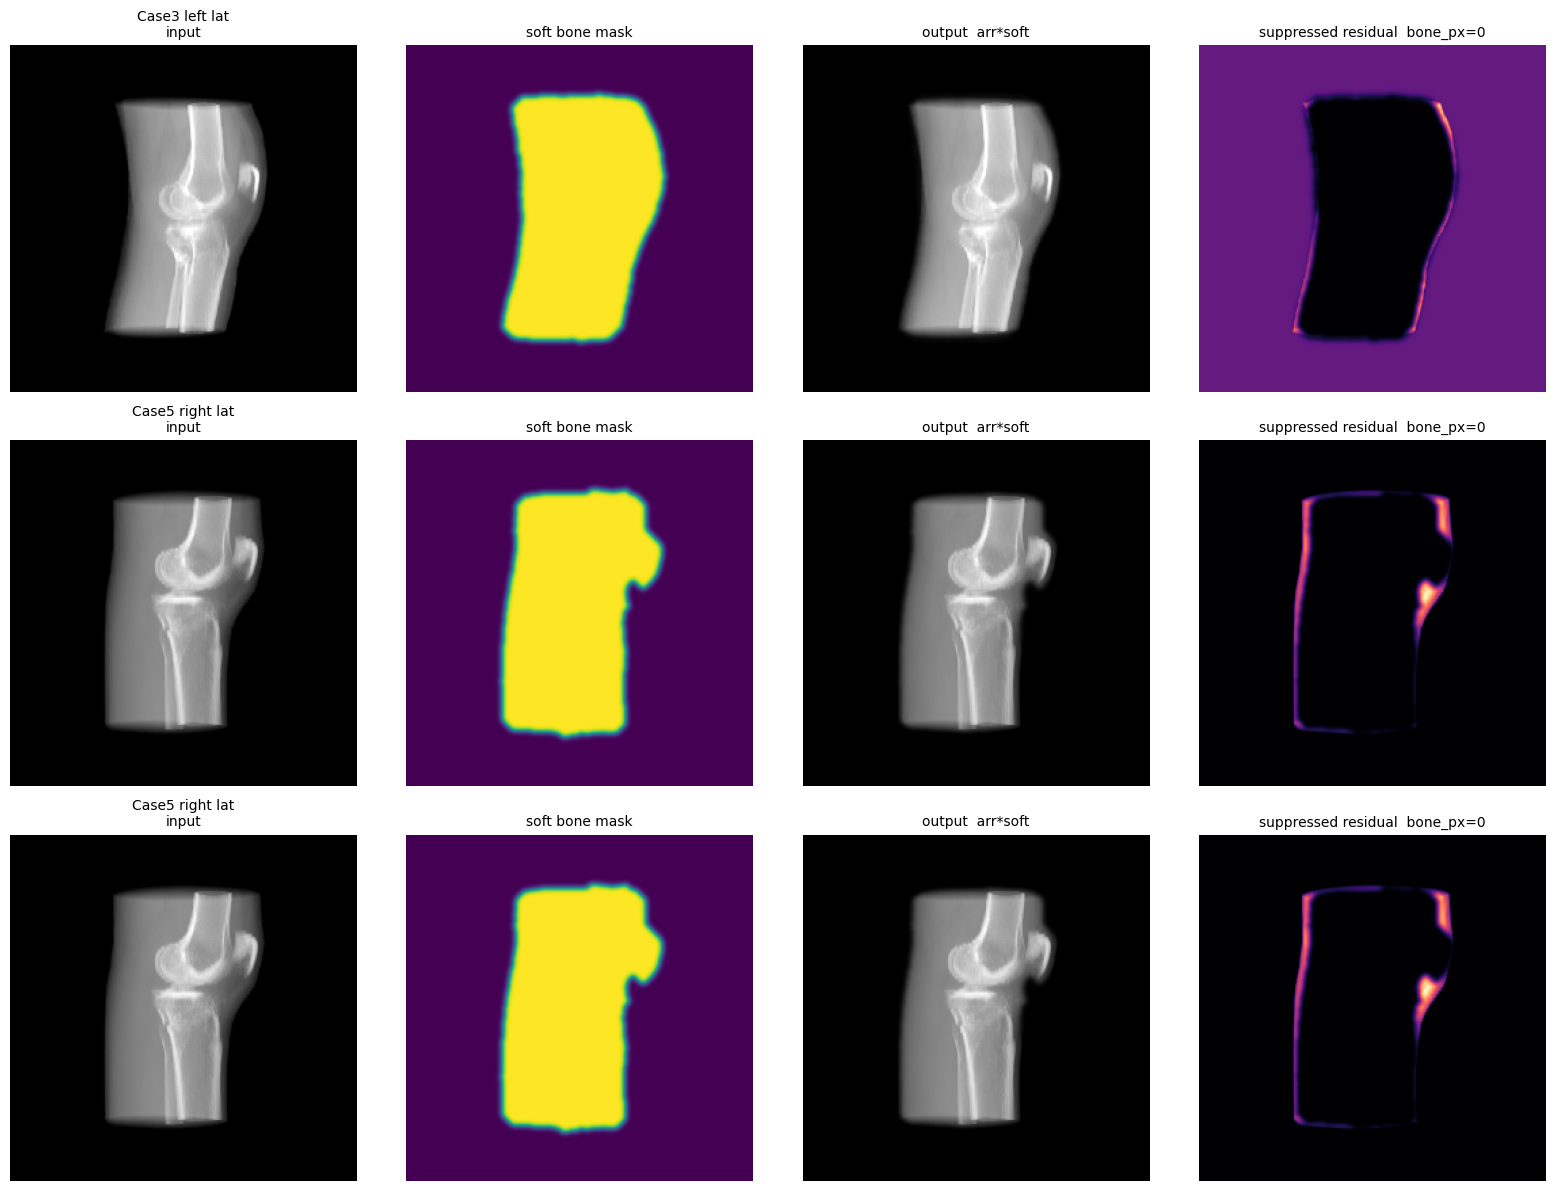

In [4]:
# --- Bone-focused DRR mask + Step-0 fracture-safety gate -----------------------------------------
# The encoder fires on the soft-tissue skin->air silhouette (the vertical stripes in the L0 features).
# A bone-focused mask suppresses that silhouette while keeping bone(+margin). Before wiring it into
# load_drr (next step), PROVE it never eats fracture energy: the suppressed residual arr*(1-soft) must
# be soft-tissue ONLY (no bone-level pixels) for every Ruikar fractured view.
import scipy.ndimage as ndi

BONE_MASK        = True   # A/B toggle vs the unmasked baseline (wired into load_drr in the next step)
BONE_THR         = 0.40   # [0,1] DRR intensity for "bone-ish"
BONE_MIN_AREA    = 0      # FRACTURE-SAFE: keep ALL bone-level components (DRRs are already speck-free)
BONE_MARGIN_PX   = 6      # dilate to keep cortical edge + cushion
BONE_FEATHER_SIG = 2.0    # px; feather so the mask edge is a gradient, not a new step

def _soft_bone_mask(arr2d):
    """HxW float32 [0,1], bg=0 -> [0,1] feathered bone mask. No distance limit so a displaced
    fragment survives even when far from the main bone. 2D bone-level analogue of predrr's
    body_envelope_mask()."""
    bone = arr2d > BONE_THR
    if BONE_MIN_AREA > 0:
        lbl, n = ndi.label(bone)
        if n:
            sizes = ndi.sum(np.ones_like(lbl), lbl, range(1, n + 1))
            bone = np.isin(lbl, 1 + np.where(sizes >= BONE_MIN_AREA)[0])
    bone = ndi.binary_fill_holes(bone)
    bone = ndi.binary_dilation(bone, iterations=BONE_MARGIN_PX)
    return np.clip(ndi.gaussian_filter(bone.astype(np.float32), BONE_FEATHER_SIG), 0, 1)

def bone_mask_drr(arr2d):
    """Keep bone(+margin), suppress the soft-tissue skin silhouette the encoder fires on."""
    return (arr2d * _soft_bone_mask(arr2d)).astype(np.float32)

# --- fracture-safety gate over every fractured view ---
frac = paired_index[paired_index.dataset == "fractured"]
_rows = []
for r in frac.itertuples(index=False):
    for view, p in [("ap", r.ap), ("lat", r.lat)]:
        arr = np.load(p).astype(np.float32)
        soft = _soft_bone_mask(arr); resid = arr * (1 - soft)
        _rows.append(dict(case=r.case, side=r.side, view=view,
                          resid_bone_px=int((resid > BONE_THR).sum()),
                          resid_max=round(float(resid.max()), 4)))
gate = pd.DataFrame(_rows).sort_values("resid_max", ascending=False).reset_index(drop=True)
leak = int((gate.resid_bone_px > 0).sum())
print(f"Fracture-safety gate: {len(gate)} views | rows with bone-level leak = {leak} "
      f"(must be 0) | worst resid_bone_px = {int(gate.resid_bone_px.max())}")
print(gate.to_string(index=False))

# four-panel eyeball for the 3 views where the mask suppresses the most (highest residual)
fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)
for i in range(3):
    row = gate.iloc[i]; rr = frac[(frac.case == row["case"]) & (frac.side == row["side"])].iloc[0]
    arr = np.load(rr.ap if row["view"] == "ap" else rr.lat).astype(np.float32)
    soft = _soft_bone_mask(arr); out = arr * soft; resid = arr * (1 - soft)
    panels = [(arr,  f"{row['case']} {row['side']} {row['view']}\ninput", 'gray'),
              (soft, "soft bone mask", 'viridis'),
              (out,  "output  arr*soft", 'gray'),
              (resid, f"suppressed residual  bone_px={int((resid > BONE_THR).sum())}", 'magma')]
    for ax, (img, ttl, cm) in zip(axes[i], panels):
        ax.imshow(img, cmap=cm); ax.set_title(ttl, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

In [5]:
class PairedDRRDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=paired_tf):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        ap = self.transform(load_drr(r.ap)); lat = self.transform(load_drr(r.lat))
        return {"ap": ap, "lat": lat, "dataset": r.dataset, "case": r.case,
                "side": r.side, "variant": r.variant, "geometric": bool(r.geometric)}

class SimCLRDRRDataset(Dataset):
    '''Every ap and lat image is an anchor; returns two stochastic views.'''
    def __init__(self, df: pd.DataFrame, aug=simclr_aug):
        recs = []
        for r in df.itertuples(index=False):
            recs.append((r.ap, r.dataset)); recs.append((r.lat, r.dataset))
        self.recs = recs; self.aug = aug
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, ds = self.recs[i]
        base = load_drr(path)
        return self.aug(base), self.aug(base), ds

# --- case-level stratified split (all variants of a knee stay together) ---
def case_split(df, val_frac=0.2, seed=SEED):
    rng = random.Random(seed); val_keys = set()
    for ds, g in df.groupby("dataset"):
        keys = sorted(g.apply(lambda r: (r["case"], r["side"]), axis=1).unique().tolist())
        rng.shuffle(keys)
        n_val = max(1, int(round(len(keys) * val_frac)))
        val_keys.update((ds, k[0], k[1]) for k in keys[:n_val])
    is_val = df.apply(lambda r: (r["dataset"], r["case"], r["side"]) in val_keys, axis=1)
    return df[~is_val].copy(), df[is_val].copy()

train_df, val_df = case_split(paired_index)
print("train pairs:", len(train_df), "| val pairs:", len(val_df))
print("train cases:", train_df.groupby("dataset")["case"].nunique().to_dict(),
      "| val cases:", val_df.groupby("dataset")["case"].nunique().to_dict())

# --- weighted sampler: oversample fractured (14) vs healthy (58) knees ---
def balanced_sampler(df):
    counts = df["dataset"].value_counts().to_dict()
    w = df["dataset"].map(lambda d: 1.0 / counts[d]).to_numpy()
    return WeightedRandomSampler(weights=torch.as_tensor(w, dtype=torch.double),
                                 num_samples=len(df), replacement=True)

train pairs: 1338 | val pairs: 360
train cases: {'fractured': 10, 'healthy': 27} | val cases: {'fractured': 3, 'healthy': 9}


## 2. SimCLR pretraining

Reuses the reference's SimCLR setup (`SimCLRModel`, NT-Xent), with the **corrected loss** and the
**shared `features_only` encoder** so the checkpoint transfers cleanly to the fusion model.
Below is a short **CPU smoke test** (loss should trend down); the full run belongs on the HPC GPU.

> **Cross-validation note.** SimCLR is **self-supervised — it uses no occupancy labels** — so for the
> k-fold comparison we pretrain it **once on ALL knees** and reuse the single fold-agnostic encoder
> across every fold. This is the plan's documented "pretrain once" option: it keeps the *label-using*
> stages (the per-fold front-end and decoder) strictly within their fold, eliminating **label**
> leakage; the only residual is a mild *representation* leakage (the encoder has seen each fold's test
> *images*, never its labels), which is the standard accepted trade-off in low-data regimes. To
> instead pretrain a per-fold encoder, restrict the dataset below to that fold's train knees and tag
> the checkpoint with the fold — at 5x the SSL cost.

In [6]:
class SimCLRModel(nn.Module):
    def __init__(self, proj_dim=128, pretrained=PRETRAINED):
        super().__init__()
        self.encoder = make_backbone(pretrained)
        fd = self.encoder.feature_info[-1]["num_chs"]
        self.projector = nn.Sequential(nn.Linear(fd, fd), nn.ReLU(), nn.Linear(fd, proj_dim))
    def forward(self, x):
        pooled = self.encoder(x)[-1].mean(dim=(2, 3))   # GAP on deepest map -> [B, fd]
        return F.normalize(self.projector(pooled), dim=1)

def nt_xent_loss(z1, z2, temperature=0.5):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    labels = torch.cat([torch.arange(B) + B, torch.arange(B)]).to(z.device)   # i<->i+B
    sim.masked_fill_(torch.eye(2 * B, dtype=torch.bool, device=z.device), -9e15)
    return F.cross_entropy(sim, labels)

In [7]:
# --- SimCLR CPU smoke test: a few steps, confirm loss decreases ---
# SSL uses ALL knees (no labels -> fold-agnostic encoder; see the CV note above), so we pretrain on
# paired_index rather than a single train split.
SMOKE_STEPS, SMOKE_BS = 10, 4
simclr_ds = SimCLRDRRDataset(paired_index)
simclr_dl = DataLoader(simclr_ds, batch_size=SMOKE_BS, shuffle=True, num_workers=0, drop_last=True)
print("SimCLR anchor images (all knees):", len(simclr_ds))

simclr = SimCLRModel().to(device).train()
opt = torch.optim.Adam(simclr.parameters(), lr=3e-4)

losses = []
it = iter(simclr_dl)
for step in range(SMOKE_STEPS):
    try:    v1, v2, _ = next(it)
    except StopIteration:
        it = iter(simclr_dl); v1, v2, _ = next(it)
    v1, v2 = v1.to(device), v2.to(device)
    loss = nt_xent_loss(simclr(v1), simclr(v2))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    print(f"step {step+1:02d}/{SMOKE_STEPS}  nt_xent={loss.item():.4f}")

print(f"\nfirst={losses[0]:.4f}  last={losses[-1]:.4f}  -> {'DOWN ok' if losses[-1] < losses[0] else 'NOT down (run more steps)'}")

# save encoder-only checkpoint (full run on HPC should overwrite this)
ckpt = MODELS_DIR / "convnextv2_simclr_encoder.pth"
torch.save(simclr.encoder.state_dict(), ckpt)
print("saved:", ckpt)

SimCLR anchor images (all knees): 3396


step 01/10  nt_xent=1.8153
step 02/10  nt_xent=1.8771
step 03/10  nt_xent=1.8084
step 04/10  nt_xent=1.4482
step 05/10  nt_xent=1.9045
step 06/10  nt_xent=1.7147
step 07/10  nt_xent=1.9446
step 08/10  nt_xent=1.4656
step 09/10  nt_xent=1.9003
step 10/10  nt_xent=1.9904

first=1.8153  last=1.9904  -> NOT down (run more steps)
saved: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\models\convnextv2_simclr_encoder.pth


## 3. Encoder + hybrid bi-planar fusion + orthogonal 2D→3D lift

**Hybrid fusion** drives the 2D feature-viz; the **lift** is what builds the 3D features. Per scale
(`FUSION_TYPES`, fine→coarse):
- `attn` (coarse stages 16²/8²): full cross-attention — *global* AP↔LAT shape correspondence, cheap (≤256 tokens).
- `local` (fine stages 64²/32²): `concat(ap,lat) → 3×3 conv (+ residual)` — preserves *fine-grain local* detail at high resolution without the 4096² attention the reference would incur at 256².

The **2D→3D lift is an orthogonal back-projection** (replacing the reference's extrude-one-map-along-Z,
which made the 3D features constant along depth and capped occupancy Dice ≈ 0.45). Each view keeps the
two volume axes it actually resolves and is broadcast along the axis it does **not** see — AP along A-P
(axis1), LAT along L-R (axis0), both sharing S-I (axis2) — then the two view cubes are fused with a 3D
conv. The cube is ordered `(axis0=L-R, axis1=A-P, axis2=S-I)` to match the GT array. Axis/flip mapping
is resolved empirically (`_axis_probe`) and guarded by Check 2 (per-axis variance) below.
Output: 4 multi-scale **cube** 3D features with channels `[64,128,256,512]` — the decoder contract.

In [8]:
class CrossAttention(nn.Module):
    '''ap (query) attends to lat (key/value). Operates on tokens [B, N, C].'''
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim); self.k = nn.Linear(dim, dim); self.v = nn.Linear(dim, dim)
        self.scale = dim ** -0.5
    def forward(self, a, b):
        attn = F.softmax(torch.matmul(self.q(a), self.k(b).transpose(-2, -1)) * self.scale, dim=-1)
        return torch.matmul(attn, self.v(b)) + a            # residual on the query view

class LocalFusion(nn.Module):
    '''Cheap high-res fusion: concat views + 3x3 conv mix, residual on ap.'''
    def __init__(self, dim):
        super().__init__()
        self.mix = nn.Conv2d(2 * dim, dim, kernel_size=3, padding=1)
    def forward(self, a, b):
        return self.mix(torch.cat([a, b], dim=1)) + a       # [B, C, H, W]

# --- bi-planar lift orientation (resolved empirically; see Check 1 / _axis_probe) ---
# GT array axes, from nibabel axcodes ('L','P','S'): axis0 = L-R, axis1 = A-P, axis2 = S-I.
# AP projects along A-P (axis1); LAT projects along L-R (axis0). Both DRR rows (H) = S-I (axis2);
# AP cols (W) = L-R (axis0); LAT cols (W) = A-P (axis1). The fused cube is ordered (axis0, axis1,
# axis2) so it matches the GT array directly. flip_* reverse a row/col direction vs its volume
# axis; locked from the affine + 1-D S-I profile test and re-confirmed by the one-sample overfit
# guard in the smoke test (a mis-flip cannot overfit a single volume).
LIFT_FLIP_SI      = False   # DRR rows  vs axis2 (S-I)
LIFT_FLIP_AP_COL  = False   # AP  cols  vs axis0 (L-R)
LIFT_FLIP_LAT_COL = True    # LAT cols  vs axis1 (A-P)

class BiPlanarFeatureFusion(nn.Module):
    def __init__(self, feat_dims=FEAT_DIMS, out_channels=OUT_CHANNELS,
                 fusion_types=FUSION_TYPES, depth=DEPTH, pretrained=PRETRAINED,
                 freeze_encoder=FREEZE_ENCODER):
        super().__init__()
        self.encoder = make_backbone(pretrained)
        self.fusion_types = list(fusion_types)
        self.depth = depth   # retained for signature compat; the orthogonal lift no longer uses it
        self.fuse = nn.ModuleList([
            CrossAttention(d) if t == "attn" else LocalFusion(d)
            for d, t in zip(feat_dims, fusion_types)])
        self.to3d = nn.ModuleList([nn.Conv2d(c, o, 1) for c, o in zip(feat_dims, out_channels)])
        # expand3d fuses the two orthogonally back-projected view cubes (2*o -> o) in 3D
        self.expand3d = nn.ModuleList([nn.Conv3d(2 * o, o, 3, padding=1) for o in out_channels])
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False

    def load_simclr_encoder(self, path):
        missing, unexpected = self.encoder.load_state_dict(torch.load(path, map_location="cpu"),
                                                            strict=False)
        print(f"loaded SimCLR encoder from {Path(path).name}: missing={len(missing)} unexpected={len(unexpected)}")
        return missing, unexpected

    def _ortho_lift(self, ap_f, lat_f, c2d, c3d):
        '''Orthogonal back-projection lift. Each view is placed on the two volume axes it actually
        resolves and broadcast along its (unobserved) projection axis; the two view cubes are then
        fused in 3D. This preserves bi-planar depth instead of extruding one fused 2D map along Z.
        Output cube is ordered (axis0=L-R, axis1=A-P, axis2=S-I) to match the GT array.'''
        B, C, H, W = ap_f.shape           # square feature map at this level: S = H = W
        S = H
        ap = c2d(ap_f); lat = c2d(lat_f)  # shared 1x1 projection -> [B, O, H, W] each
        O = ap.shape[1]
        if LIFT_FLIP_SI:      ap = ap.flip(2); lat = lat.flip(2)   # rows (H) = S-I (axis2)
        if LIFT_FLIP_AP_COL:  ap = ap.flip(3)                       # AP  cols (W) = L-R (axis0)
        if LIFT_FLIP_LAT_COL: lat = lat.flip(3)                     # LAT cols (W) = A-P (axis1)
        # AP: (H=axis2, W=axis0) -> cube (axis0, axis1, axis2), broadcast over axis1 (A-P)
        ap_cube = ap.permute(0, 1, 3, 2).unsqueeze(3).expand(B, O, S, S, S)
        # LAT: (H=axis2, W=axis1) -> cube (axis0, axis1, axis2), broadcast over axis0 (L-R)
        lat_cube = lat.permute(0, 1, 3, 2).unsqueeze(2).expand(B, O, S, S, S)
        return c3d(torch.cat([ap_cube, lat_cube], dim=1))           # [B, O, S, S, S]

    def forward(self, ap_img, lat_img):
        ap_feats, lat_feats = self.encoder(ap_img), self.encoder(lat_img)
        fused2d, fused3d = [], []
        for ap_f, lat_f, fuse, c2d, c3d, t in zip(
            ap_feats, lat_feats, self.fuse, self.to3d, self.expand3d, self.fusion_types):
            B, C, H, W = ap_f.shape
            if t == "attn":
                a = ap_f.flatten(2).transpose(1, 2); b = lat_f.flatten(2).transpose(1, 2)
                f2d = fuse(a, b).transpose(1, 2).reshape(B, C, H, W)
            else:
                f2d = fuse(ap_f, lat_f)
            fused2d.append(f2d)                                  # kept only for the feature-viz cells
            fused3d.append(self._ortho_lift(ap_f, lat_f, c2d, c3d))
        return fused2d, fused3d

## 4. 3D feature smoke test + visual QA

Forward one **healthy** and one **fractured** real DRR pair; assert the four 3D feature shapes
match the decoder contract; then visualize inputs + a few fused feature channels.

In [9]:
fusion = BiPlanarFeatureFusion().to(device).eval()
ckpt = MODELS_DIR / "convnextv2_simclr_encoder.pth"
if ckpt.exists():
    fusion.load_simclr_encoder(ckpt)

def first_pair(df, dataset):
    sub = df[df.dataset == dataset]
    return sub.iloc[0] if len(sub) else None

# orthogonal lift -> CUBE features: depth == height == width == IMG_SIZE//stride at each level
expected = [(c, IMG_SIZE // s) for c, s in zip(OUT_CHANNELS, [4, 8, 16, 32])]  # (channels, side)
samples = {ds: first_pair(paired_index, ds) for ds in ["healthy", "fractured"]}

f3d = None
for ds, r in samples.items():
    if r is None:
        print(f"[skip] no {ds} pair found"); continue
    ap = paired_tf(load_drr(r.ap)).unsqueeze(0).to(device)
    lat = paired_tf(load_drr(r.lat)).unsqueeze(0).to(device)
    with torch.no_grad():
        _, f3d = fusion(ap, lat)
    print(f"\n{ds}: {r.case} {r.side} ({r.variant})")
    for i, (f, (ec, es)) in enumerate(zip(f3d, expected)):
        B, C, D, H, W = f.shape
        ok = (C == ec and D == es and H == es and W == es)
        print(f"  level{i}: {tuple(f.shape)}  expect C={ec}, DxHxW={es}^3  {'OK' if ok else 'MISMATCH'}")
        assert ok, f"feature {i} shape mismatch (expected cube {es}^3)"
print("\nAll 3D feature shapes match the decoder contract (cube features).")

# --- Check 2: per-axis feature variance (extrusion detector) -------------------------------------
# The reference lift broadcast one fused 2D map along depth -> std==0 along that axis (the bug that
# capped Dice ~0.45). The orthogonal lift must vary along ALL THREE spatial axes. FAIL loudly if any
# axis collapses, so a regression to an extruding lift cannot pass silently.
print("\nCheck 2 — per-axis feature std (mean over batch,channel); every axis must be > 1e-4:")
assert f3d is not None, "no features produced; cannot run Check 2"
for i, f in enumerate(f3d):
    s0 = f.std(dim=2).mean().item()   # along axis0 (L-R)
    s1 = f.std(dim=3).mean().item()   # along axis1 (A-P)
    s2 = f.std(dim=4).mean().item()   # along axis2 (S-I)
    ok = min(s0, s1, s2) > 1e-4
    print(f"  level{i}: std[axis0]={s0:.4f} std[axis1]={s1:.4f} std[axis2]={s2:.4f}  "
          f"{'OK' if ok else 'FAIL — axis collapsed (extrusion bug!)'}")
    assert ok, f"level{i} collapses along an axis — the lift is extruding, not back-projecting"
print("Check 2 PASS: 3D features vary on all three axes (no extrusion).")

loaded SimCLR encoder from convnextv2_simclr_encoder.pth: missing=0 unexpected=0

healthy: VSD_002 left (normal)
  level0: (1, 64, 64, 64, 64)  expect C=64, DxHxW=64^3  OK
  level1: (1, 128, 32, 32, 32)  expect C=128, DxHxW=32^3  OK
  level2: (1, 256, 16, 16, 16)  expect C=256, DxHxW=16^3  OK
  level3: (1, 512, 8, 8, 8)  expect C=512, DxHxW=8^3  OK

fractured: Case11 right (normal)
  level0: (1, 64, 64, 64, 64)  expect C=64, DxHxW=64^3  OK
  level1: (1, 128, 32, 32, 32)  expect C=128, DxHxW=32^3  OK
  level2: (1, 256, 16, 16, 16)  expect C=256, DxHxW=16^3  OK
  level3: (1, 512, 8, 8, 8)  expect C=512, DxHxW=8^3  OK

All 3D feature shapes match the decoder contract (cube features).

Check 2 — per-axis feature std (mean over batch,channel); every axis must be > 1e-4:
  level0: std[axis0]=0.1121 std[axis1]=0.1099 std[axis2]=0.1224  OK
  level1: std[axis0]=0.2089 std[axis1]=0.2072 std[axis2]=0.2428  OK
  level2: std[axis0]=1.9998 std[axis1]=2.1253 std[axis2]=2.1566  OK
  level3: std[axis0]

finest stage tokens: 4096  | all-attn matrix/sample: 16,777,216 floats (~67 MB fp32)  -> hybrid uses conv here instead.


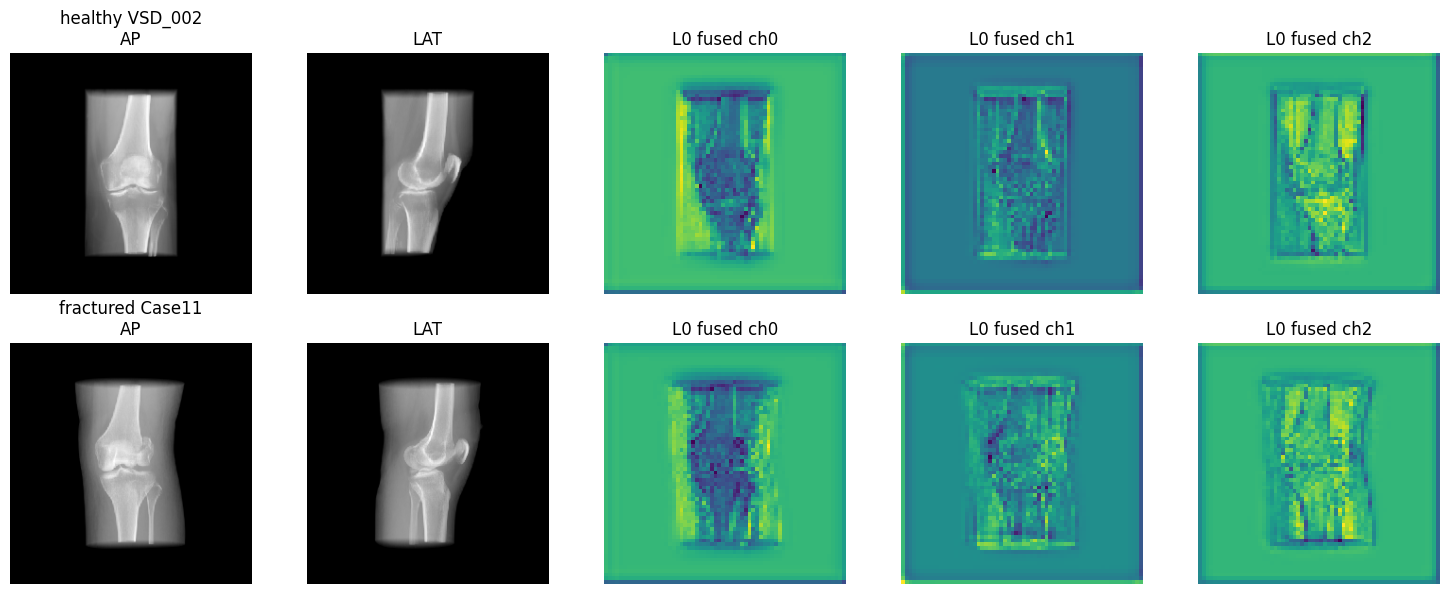

In [10]:
# --- memory note: hybrid vs all-attention fusion at 256^2 (finest stage = 64x64 = 4096 tokens) ---
n_fine = (IMG_SIZE // 4) ** 2
print(f"finest stage tokens: {n_fine}  | all-attn matrix/sample: {n_fine**2:,} floats "
      f"(~{n_fine**2*4/1e6:.0f} MB fp32)  -> hybrid uses conv here instead.")

# --- visual QA: inputs + a few fused feature channels (level 0, the high-res local features) ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (ds, r) in enumerate(samples.items()):
    if r is None: continue
    ap = paired_tf(load_drr(r.ap)).unsqueeze(0).to(device)
    lat = paired_tf(load_drr(r.lat)).unsqueeze(0).to(device)
    with torch.no_grad():
        f2d, _ = fusion(ap, lat)
    axes[row, 0].imshow(load_drr(r.ap)[0], cmap="gray"); axes[row, 0].set_title(f"{ds} {r.case}\nAP")
    axes[row, 1].imshow(load_drr(r.lat)[0], cmap="gray"); axes[row, 1].set_title("LAT")
    fmap = f2d[0][0].cpu()   # level-0 fused features [C,64,64]
    for j in range(3):
        axes[row, 2 + j].imshow(fmap[j], cmap="viridis"); axes[row, 2 + j].set_title(f"L0 fused ch{j}")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Deferred work (documented, not built here)

This notebook stops at reusable 3D features. The next stages:

1. **Decoder + supervised training** — attach a 3D U-Net and a V-Net to `fused3d` and train with the
   **same** loss (BCE+Dice, now multi-channel over the 4 bones), so only the decoder differs (the
   baseline comparison). See `02_frontend_pretrain.ipynb` (front-end freeze) then `03_decoder_pipeline.ipynb`.
2. **GT per-bone occupancy** — load the 4-channel STL-derived masks from
   `data/interim/gt_per_bone_256/{dataset}/{key}/{key}_{bone}.nii.gz` (femur/tibia/patella/fibula,
   built by `00_gt_per_bone.ipynb`); resample each bone to the decoder output grid and pair via
   `(dataset,case,side)`. This replaces the earlier `predrr > threshold` binary occupancy target
   (density-confounded on dim-CT bone).
3. **Geometric augmentation** — for rows with `geometric=True` (rotation≠0 or flip), apply the *same*
   transform to the 3D GT before the loss; photometric-only rows pair with the unmodified GT.
4. **Joint fine-tuning** — unfreeze the encoder (already `FREEZE_ENCODER=False`) and fine-tune end-to-end.
5. **HPC scale-up** — full SimCLR run on GPU, 256³ target; mirror into `HPC/HPC_notebooks/` (POSIX paths).